In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedGroupKFold

In [2]:
data_path = "/Heart-Disease-UCI.csv"
data = pd.read_csv(data_path)
print(data.info())
print(data.head())


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0  

In [3]:
# # Define features and labels
X = data.iloc[:, :-1]  
Y = data.iloc[:, -1]   

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Show the number of samples in training and test sets
print("Training samples:", len(Y_train))
print("Test samples:", len(Y_test))

Training samples: 242
Test samples: 61


In [4]:
clf = MultinomialNB(alpha=1.0, fit_prior=True)
clf.fit(X_train, Y_train)
prediction_prob = clf.predict_proba(X_test)
print(prediction_prob[0:10])

prediction = clf.predict(X_test)
print(prediction[:10])

accuracy = clf.score(X_test, Y_test)
print(f"The accuracy is: {accuracy*100:.1f}%")

[[9.99494719e-01 5.05280507e-04]
 [1.13089677e-01 8.86910323e-01]
 [6.09067753e-04 9.99390932e-01]
 [9.99849664e-01 1.50336392e-04]
 [6.77547941e-01 3.22452059e-01]
 [1.91754940e-03 9.98082451e-01]
 [2.28731774e-01 7.71268226e-01]
 [9.99992191e-01 7.80935806e-06]
 [9.99964314e-01 3.56863131e-05]
 [2.70901779e-01 7.29098221e-01]]
[0 1 1 0 0 1 1 0 0 1]
The accuracy is: 85.2%


In [5]:
report = classification_report(Y_test, prediction)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



In [6]:
# Probability of the positive class
pos_prob = prediction_prob[:, 1]

# Thresholds for ROC curve calculation
thresholds = np.arange(0.0, 1.1, 0.05)

# Initialize True Positive and False Positive counters
true_pos = [0] * len(thresholds)
false_pos = [0] * len(thresholds)

# Count TP and FP for each threshold
for pred, y in zip(pos_prob, Y_test):
    for i, threshold in enumerate(thresholds):
        # If the predicted probability is greater than or equal to the threshold,
        # the sample is considered positive.
        if pred >= threshold:
            if y == 1:
                # True Positive: actual label is 1 and predicted label is also 1
                true_pos[i] += 1
            else:
                # False Positive: actual label is 0 but predicted label is 1
                false_pos[i] += 1
        else:
            # Since thresholds are increasing,
            # larger thresholds will also be greater than pred.
            break

# Number of positive and negative samples in the test set
n_pos_test = int((Y_test == 1).sum())
n_neg_test = int((Y_test == 0).sum())

# Compute True Positive Rate and False Positive Rate
# Add a small guard to avoid division by zero
true_pos_rate = np.array([
    tp / n_pos_test if n_pos_test > 0 else 0.0
    for tp in true_pos
])

false_pos_rate = np.array([
    fp / n_neg_test if n_neg_test > 0 else 0.0
    for fp in false_pos
])

# The thresholds are increasing, so ROC points are generated from (1,1) toward (0,0).
# Reverse them to plot the ROC curve in the usual direction.
true_pos_rate = true_pos_rate[::-1]
false_pos_rate = false_pos_rate[::-1]

C:\Users\Benyamin\AppData\Local\Temp\ipykernel_19808\4243235233.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


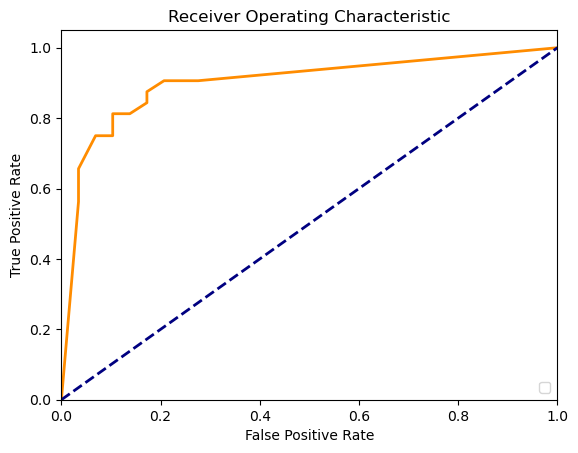

0.9181034482758621


In [7]:
plt.figure()
lw = 2
plt.plot(false_pos_rate, true_pos_rate, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(roc_auc_score(Y_test, pos_prob))

In [15]:
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# لیست‌هایی برای ذخیره نتایج هر لایه
accuracies = []
auc_scores = []

print("--- Start K-Fold Validation ---")
for fold, (train_index, val_index) in enumerate(skf.split(X, Y)):
    print(f"\n--- Fold {fold + 1} ---")
    
    # جداسازی داده‌های آموزش و اعتبارسنجی برای این لایه
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    Y_train_fold, Y_val_fold = Y.iloc[train_index], Y.iloc[val_index]
    
    # تعریف و آموزش مدل (برای هر لایه باید یک مدل جدید ساخته شود)
    clf = MultinomialNB(alpha=1.0, fit_prior=True)
    clf.fit(X_train_fold, Y_train_fold)
    
    # پیش‌بینی و محاسبه احتمالات
    Y_pred_fold = clf.predict(X_val_fold)
    Y_prob_fold = clf.predict_proba(X_val_fold)[:, 1]
    
    # محاسبه معیارها
    acc = accuracy_score(Y_val_fold, Y_pred_fold)
    auc = roc_auc_score(Y_val_fold, Y_prob_fold)
    
    accuracies.append(acc)
    auc_scores.append(auc)
    
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"AUC: {auc:.4f}")

# محاسبه و چاپ نتایج نهایی (میانگین و انحراف معیار)
print("\n" + "="*30)
print("--- K-Fold Final Results ---")
print(f"Mean Accuracy: {np.mean(accuracies)*100:.2f}% (+/- {np.std(accuracies)*100:.2f}%)")
print(f"Mean AUC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")

--- Start K-Fold Validation ---

--- Fold 1 ---
Accuracy: 83.61%
AUC: 0.9134

--- Fold 2 ---
Accuracy: 77.05%
AUC: 0.8820

--- Fold 3 ---
Accuracy: 75.41%
AUC: 0.8193

--- Fold 4 ---
Accuracy: 75.00%
AUC: 0.8384

--- Fold 5 ---
Accuracy: 65.00%
AUC: 0.7811

--- K-Fold Final Results ---
Mean Accuracy: 75.21% (+/- 5.97%)
Mean AUC: 0.8468 (+/- 0.0465)
